# MathNet CNN Math Problem Detection & Understanding
Uses the `ShadenA/MathNet` dataset with a CNN-based classifier to categorize math problems by topic.

## 1. Install Dependencies

In [1]:
!pip install tensorflow keras matplotlib scikit-learn seaborn pandas numpy pyarrow

## 2. Load the Dataset

In [2]:
import os

if not os.path.exists("MathNet"):
    !git lfs install
    !git clone https://huggingface.co/datasets/ShadenA/MathNet
    print("MathNet cloned successfully.")
else:
    print("MathNet directory already exists — skipping clone.")

Git LFS initialized.
Cloning into 'MathNet'...
remote: Enumerating objects: 783, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 783 (delta 6), reused 0 (delta 0), pack-reused 771 (from 1)
Receiving objects: 100% (783/783), 137.11 KiB | 521.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.
Filtering content: 100% (695/695), 703.91 MiB | 23.28 MiB/s, done.
MathNet cloned successfully.


In [3]:
import pandas as pd
import glob
import os
from concurrent.futures import ThreadPoolExecutor

files = sorted(glob.glob("MathNet/data/all/train-*.parquet"))
N_WORKERS = min(os.cpu_count(), len(files))
print(f"Loading {len(files)} parquet files with {N_WORKERS} workers...")

with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    dfs = list(pool.map(pd.read_parquet, files))

df_full = pd.concat(dfs, ignore_index=True)
print(f"Total rows loaded: {len(df_full):,}")
print("Columns:", df_full.columns.tolist())

df_train = df_full.reset_index(drop=True)
print(f"\nRows available for training: {len(df_train):,}")

Loading 56 parquet files with 2 workers...
Total rows loaded: 27,817
Columns: ['id', 'problem_markdown', 'solutions_markdown', 'images', 'country', 'competition', 'topics_flat', 'language', 'problem_type', 'final_answer']

Rows available for training: 27,817


Rows per country:
country
United States                                      4819
Romania                                            1905
Brazil                                             1281
Slovenia                                            991
Saudi Arabia                                        908
Baltic Way                                          853
Ukraine                                             847
France                                              816
China                                               719
Philippines                                         710
Italy                                               673
Croatia                                             659
Spain                                               607
Mongolia                                            589
Belarus                                             579
Soviet Union                                        549
Bulgaria                                            546
Netherlands           

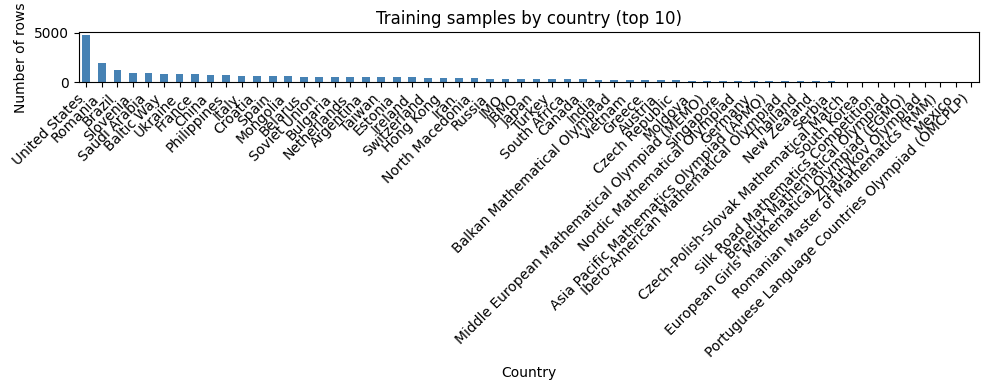

In [4]:
import matplotlib.pyplot as plt

if "country" in df_train.columns:
    country_counts = df_train["country"].value_counts()
    print("Rows per country:")
    print(country_counts.to_string())

    plt.figure(figsize=(10, 4))
    country_counts.plot(kind="bar", color="steelblue")
    plt.title("Training samples by country (top 10)")
    plt.xlabel("Country")
    plt.ylabel("Number of rows")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'country' column in dataset.")

## 3. Explore the Dataset

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Columns:", df_train.columns.tolist())
print("Shape:", df_train.shape)
df_train.head()

Columns: ['id', 'problem_markdown', 'solutions_markdown', 'images', 'country', 'competition', 'topics_flat', 'language', 'problem_type', 'final_answer']
Shape: (27817, 10)


,id,problem_markdown,solutions_markdown,images,country,competition,topics_flat,language,problem_type,final_answer
0,009s,Each cell of an $n \times n$ grid square is co...,"[Color row 1 black and rows 2, 3 white. Then e...",[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,Argentina,NATIONAL XXX OMA,[Discrete Mathematics > Combinatorics > Colori...,None,proof and answer,n ≡ 1 (mod 3)
1,00hy,"There are $n$ line segments on the plane, no t...",[Draw a circle that encloses all the intersect...,[{'bytes': b'\xff\xd8\xff\xdb\x00\x84\x00\x08\...,Asia Pacific Mathematics Olympiad (APMO),APMO,[Geometry > Plane Geometry > Miscellaneous > C...,English,proof only,None
2,00k4,Let $ABCDEF$ be a regular octahedron with lowe...,[![](attached_image_1.png)\nWe intersect the e...,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,Austria,AustriaMO2013,"[Geometry > Solid Geometry > 3D Shapes, Geomet...",English,proof only,None
3,00rl,The point $M$ lies on the side $AB$ of the cir...,[Lemma. Let $I$ be the incenter of $\triangle ...,[{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIH...,Balkan Mathematical Olympiad,BMO 2016 Short List Final,[Geometry > Plane Geometry > Triangles > Trian...,None,proof only,None
4,00xp,Problem:\n\nA square is divided into 16 equal ...,[Solution:\n\nThe example in Figure 3a demonst...,[{'bytes': b'\xff\xd8\xff\xdb\x00\x84\x00\x08\...,Baltic Way,Baltic Way 1993,[Discrete Mathematics > Combinatorics > Colori...,None,proof and answer,8


Using label column: topics_flat
Source: 27,817 rows
Counted 11 unique top-level categories.


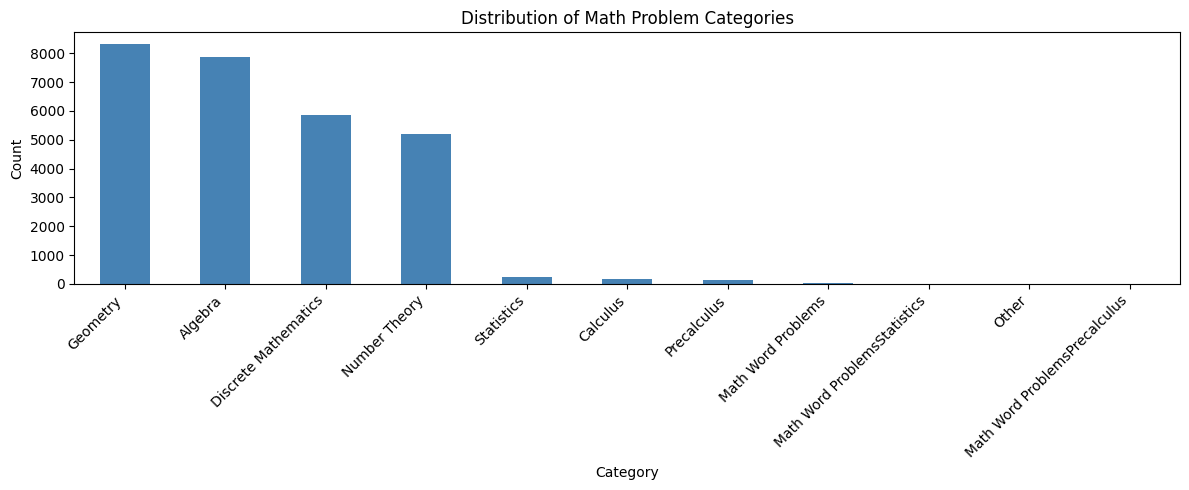

In [6]:
import os
import ast
import matplotlib.pyplot as plt

label_col = "topics_flat"
print("Using label column:", label_col)

# Use df_full so this works even when no images are available (df_train may be empty)
source_df = df_full if len(df_full) > 0 else df_train
print(f"Source: {len(source_df):,} rows")

def get_top_category(val):
    try:
        topics = val if isinstance(val, list) else ast.literal_eval(str(val))
        if topics:
            return topics[0].split(">")[0].strip()
    except Exception:
        pass
    return "Other"

label_counts = source_df[label_col].apply(get_top_category).value_counts().sort_values(ascending=False)
print(f"Counted {len(label_counts)} unique top-level categories.")

if len(label_counts) == 0:
    print("No label data found — skipping plot.")
else:
    plt.figure(figsize=(12, 5))
    label_counts.plot(kind="bar", color="steelblue")
    plt.title("Distribution of Math Problem Categories")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Preprocess â€” Tokenise Text for 1-D CNN

In [7]:
import ast
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences

text_col = "problem_markdown"
print("Text column:", text_col, "| Label column:", label_col)

# Use the full dataset for text classification
df_text = df_full.dropna(subset=[text_col, label_col]).reset_index(drop=True)
print(f"Using full dataset: {len(df_text):,} rows")

# Keep only the 4 well-represented classes (each with 5000+ examples).
# Statistics, Calculus, Precalculus, and Math Word Problems together have < 600
# examples total — too few for a CNN to learn reliably — so they are dropped.
CATEGORY_MAP = {
    "Algebra":              "Algebra",
    "Number Theory":        "Number Theory",
    "Geometry":             "Geometry",
    "Trigonometry":         "Geometry",
    "Discrete Mathematics": "Combinatorics",
    "Combinatorics":        "Combinatorics",
}

def extract_top_label(topics_raw):
    try:
        topics = topics_raw if isinstance(topics_raw, list) else ast.literal_eval(str(topics_raw))
        if topics:
            top = topics[0].split(">")[0].strip()
            return CATEGORY_MAP.get(top)  # None for unmapped topics
    except Exception:
        pass
    return None

df_text["label"] = df_text[label_col].apply(extract_top_label)

before = len(df_text)
df_text = df_text[df_text["label"].notna()].reset_index(drop=True)
print(f"Dropped {before - len(df_text):,} rows with rare/unmapped classes → {len(df_text):,} remain")

print("Category distribution:")
print(df_text["label"].value_counts().to_string())

le = LabelEncoder()
y_all = le.fit_transform(df_text["label"])
num_classes = len(le.classes_)
print(f"Classes ({num_classes}):", le.classes_)

MAX_WORDS = 20_000
MAX_LEN   = 256

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_text[text_col].astype(str))

X_all = pad_sequences(
    tokenizer.texts_to_sequences(df_text[text_col].astype(str)),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
print("X shape:", X_all.shape, "| y shape:", y_all.shape)

Text column: problem_markdown | Label column: topics_flat
Using full dataset: 27,817 rows
Dropped 586 rows with rare/unmapped classes → 27,231 remain
Category distribution:
label
Geometry         8313
Algebra          7859
Combinatorics    5864
Number Theory    5195
Classes (4): ['Algebra' 'Combinatorics' 'Geometry' 'Number Theory']
X shape: (27231, 256) | y shape: (27231,)


## 5. Train / Validation Split

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

class_counts = np.bincount(y_all)

if class_counts.min() >= 2:
    stratify_labels = y_all
    print("Using stratified split.")
else:
    stratify_labels = None
    print("Some classes have only 1 example, so using a regular random split.")

X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels,
)
print("Train:", X_train.shape, "| Val:", X_val.shape)

Using stratified split.
Train: (21784, 256) | Val: (5447, 256)


## 5b. Ridge Classifier Baseline

A **Ridge Classifier** (multi-class linear classifier via L2-regularised least-squares) paired with **TF-IDF** features is a strong, interpretable baseline for this problem.

**Why it is a useful baseline here:**
- Math competition problems contain highly distinctive vocabulary (*congruent*, *modulo*, *polynomial*, *permutation*) that TF-IDF captures well without any sequence modelling.
- `RidgeClassifier` trains in seconds on ~20 k problems, making it easy to iterate on feature engineering without GPU time.
- If a simple linear model already achieves high accuracy, it signals that **lexical cues dominate**; a neural model that barely improves over Ridge is likely not learning meaningful extra structure.
- Conversely, a large gap between Ridge and a neural model confirms that word order, long-range dependencies, or mathematical notation patterns genuinely matter.

Pipeline: `TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)` → `RidgeClassifier(alpha=1.0)`, trained on the same 80 / 20 stratified split as the CNN and Transformer.


Ridge train: 21,784 | val: 5,447

Ridge Classifier — Validation Accuracy: 85.75%

               precision    recall  f1-score   support

      Algebra       0.84      0.85      0.84      1572
Combinatorics       0.80      0.83      0.81      1173
     Geometry       0.96      0.94      0.95      1663
Number Theory       0.80      0.78      0.79      1039

     accuracy                           0.86      5447
    macro avg       0.85      0.85      0.85      5447
 weighted avg       0.86      0.86      0.86      5447



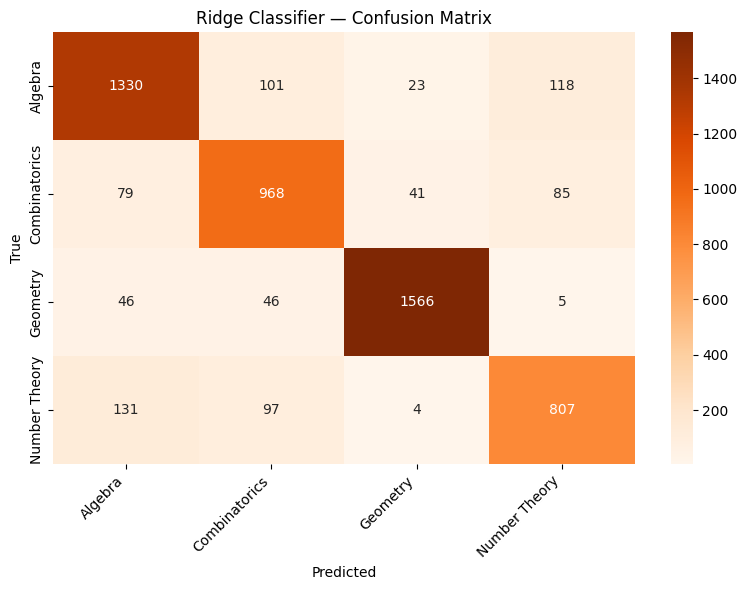

In [9]:
from sklearn.linear_model import RidgeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split as _tts

# Recreate the same 80/20 stratified split on raw text (random_state=42 matches neural split)
_text_raw = df_text[text_col].astype(str).values

text_train_raw, text_val_raw, y_train_ridge, y_val_ridge = _tts(
    _text_raw, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)
print(f"Ridge train: {len(text_train_raw):,} | val: {len(text_val_raw):,}")

# TF-IDF: unigrams + bigrams, sublinear TF scaling
tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(text_train_raw)
X_val_tfidf   = tfidf.transform(text_val_raw)

# Train
ridge_clf = RidgeClassifier(alpha=1.0)
ridge_clf.fit(X_train_tfidf, y_train_ridge)

# Evaluate
y_pred_ridge  = ridge_clf.predict(X_val_tfidf)
ridge_val_acc = accuracy_score(y_val_ridge, y_pred_ridge)
print(f"\nRidge Classifier — Validation Accuracy: {ridge_val_acc:.2%}\n")

present_labels_r = np.union1d(np.unique(y_val_ridge), np.unique(y_pred_ridge))
present_names_r  = le.classes_[present_labels_r]
print(classification_report(y_val_ridge, y_pred_ridge,
                             labels=present_labels_r, target_names=present_names_r))

cm_ridge = confusion_matrix(y_val_ridge, y_pred_ridge, labels=present_labels_r)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ridge, annot=True, fmt="d", cmap="Oranges",
            xticklabels=present_names_r, yticklabels=present_names_r)
plt.title("Ridge Classifier — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Build the 1-D CNN Model

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

EMBED_DIM = 128

def build_cnn(vocab_size, embed_dim, seq_len, num_classes):
    inp = layers.Input(shape=(seq_len,))

    # Embedding with spatial dropout
    x = layers.Embedding(vocab_size, embed_dim)(inp)
    x = layers.SpatialDropout1D(0.2)(x)

    # Parallel conv branches — kernel sizes 2–7 capture short to long n-gram patterns
    branches = []
    for k in (2, 3, 4, 5, 6, 7):
        b = layers.Conv1D(128, k, activation="relu", padding="same",
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        b = layers.BatchNormalization()(b)
        b = layers.Conv1D(64, k, activation="relu", padding="same",
                          kernel_regularizer=regularizers.l2(1e-4))(b)
        b = layers.BatchNormalization()(b)
        b = layers.GlobalMaxPooling1D()(b)
        branches.append(b)

    # Also add a global average pool branch on the raw embedding for softer context
    avg = layers.GlobalAveragePooling1D()(x)
    branches.append(avg)

    merged = layers.Concatenate()(branches)          # 6*64 + embed_dim = 512-dim

    # Deep classification head
    merged = layers.Dense(512, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.5)(merged)

    merged = layers.Dense(256, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.4)(merged)

    merged = layers.Dense(128, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.3)(merged)

    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(0.2)(merged)

    out = layers.Dense(num_classes, activation="softmax")(merged)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_cnn(MAX_WORDS, EMBED_DIM, MAX_LEN, num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 256, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 128)  │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 256, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 256, 128)  │     65,664 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 256, 128)  │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 256, 128)  │     98,432 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 256, 128)  │    114,816 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 256, 64)   │     16,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 256, 64)   │     24,640 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 256, 64)   │     32,832 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 256, 64)   │     41,024 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 256, 64)   │     49,216 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,668,292 (13.99 MB)

 Trainable params: 3,664,196 (13.98 MB)

 Non-trainable params: 4,096 (16.00 KB)

## 7. Train

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# Use class weights to handle class imbalance
class_counts = np.bincount(y_train)
total = len(y_train)
class_weight = {i: total / (num_classes * count) for i, count in enumerate(class_counts) if count > 0}

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 57s 94ms/step - accuracy: 0.3649 - loss: 1.8362 - val_accuracy: 0.1907 - val_loss: 6.7517 - learning_rate: 1.0000e-04
Epoch 2/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.5124 - loss: 1.4069 - val_accuracy: 0.2925 - val_loss: 2.3192 - learning_rate: 1.0000e-04
Epoch 3/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6228 - loss: 1.1682 - val_accuracy: 0.6554 - val_loss: 1.0703 - learning_rate: 1.0000e-04
Epoch 4/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.6838 - loss: 1.0436 - val_accuracy: 0.6896 - val_loss: 0.9946 - learning_rate: 1.0000e-04
Epoch 5/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.7257 - loss: 0.9486 - val_accuracy: 0.7402 - val_loss: 0.8851 - learning_rate: 1.0000e-04
Epoch 6/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.7529 - loss: 0.8832 - val_accuracy: 0.7461 - val_loss: 0.8670 - learning_rate: 1.0000e-04
Epoch 7/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/ste

## 7c. Transformer Classifier
A lightweight Transformer encoder built on the same integer-token sequences as the CNN. Each encoder block applies multi-head self-attention followed by a position-wise feed-forward network, both with residual connections and layer normalisation. Learned positional embeddings are added to the token embeddings so the model knows word order.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout):
    # Multi-Head Self-Attention with residual + LayerNorm
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout
    )(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    # Position-wise Feed-Forward with residual + LayerNorm
    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dense(embed_dim)(ffn)
    ffn = layers.Dropout(dropout)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
    return x


def build_transformer(vocab_size, embed_dim, seq_len, num_classes,
                      num_heads=4, ff_dim=256, num_blocks=2, dropout=0.1):
    inp = layers.Input(shape=(seq_len,))

    # Token embeddings + learned positional embeddings
    tok_emb = layers.Embedding(vocab_size, embed_dim)(inp)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb = layers.Embedding(seq_len, embed_dim)(positions)
    x = layers.Dropout(dropout)(tok_emb + pos_emb)

    # Stack of transformer encoder blocks
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout)

    # Pool across the sequence, then classify
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    m = models.Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m


transformer_model = build_transformer(
    vocab_size=MAX_WORDS,
    embed_dim=EMBED_DIM,
    seq_len=MAX_LEN,
    num_classes=num_classes,
)
transformer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 256, 128)  │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256, 128)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ dropout_4[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 128)  │          0 │ dropout_4[0][0],  │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256, 128)  │     32,896 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256, 128)  │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256, 128)  │     32,896 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256, 128)  │          0 │ dense_8[0][0]   

 Total params: 2,841,988 (10.84 MB)

 Trainable params: 2,841,988 (10.84 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

transformer_history = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    ],
)

Epoch 1/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 39s 68ms/step - accuracy: 0.6027 - loss: 0.9553 - val_accuracy: 0.7790 - val_loss: 0.6053 - learning_rate: 1.0000e-04
Epoch 2/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8223 - loss: 0.5084 - val_accuracy: 0.8346 - val_loss: 0.4669 - learning_rate: 1.0000e-04
Epoch 3/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8642 - loss: 0.3990 - val_accuracy: 0.8428 - val_loss: 0.4522 - learning_rate: 1.0000e-04
Epoch 4/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.8959 - loss: 0.3225 - val_accuracy: 0.8540 - val_loss: 0.4404 - learning_rate: 1.0000e-04
Epoch 5/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9098 - loss: 0.2768 - val_accuracy: 0.8392 - val_loss: 0.4962 - learning_rate: 1.0000e-04
Epoch 6/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9253 - loss: 0.2352 - val_accuracy: 0.8324 - val_loss: 0.5896 - learning_rate: 1.0000e-04
Epoch 7/20
339/341 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

## 7b. All-Model Comparison
Side-by-side parameter count and best validation accuracy for all three models.

                    Model Parameters Best Val Acc
Ridge Classifier (TF-IDF)     80,000       85.75%
            1D CNN (text)  3,668,292       83.17%
       Transformer (text)  2,841,988       85.40%


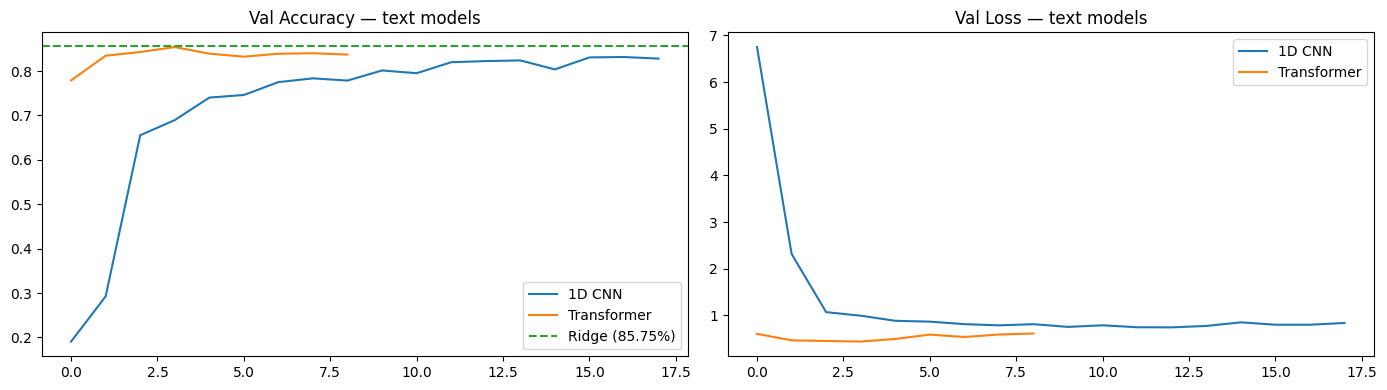

In [14]:
import pandas as pd

def _best_val_acc(hist):
    if hist is None:
        return float("nan")
    return max(hist.history["val_accuracy"])

# Ridge parameter count = coef_ matrix size (n_classes × n_tfidf_features)
ridge_params = ridge_clf.coef_.size

rows = [
    {"Model": "Ridge Classifier (TF-IDF)", "Parameters": ridge_params,                    "Best Val Acc": ridge_val_acc},
    {"Model": "1D CNN (text)",              "Parameters": model.count_params(),             "Best Val Acc": _best_val_acc(history)},
    {"Model": "Transformer (text)",         "Parameters": transformer_model.count_params(), "Best Val Acc": _best_val_acc(transformer_history)},
]
df_cmp = pd.DataFrame(rows)
df_cmp["Parameters"]   = df_cmp["Parameters"].apply(lambda x: f"{x:,}" if isinstance(x, int) else x)
df_cmp["Best Val Acc"] = df_cmp["Best Val Acc"].apply(lambda x: f"{x:.2%}" if x == x else "N/A")
print(df_cmp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for hist, label in [(history, "1D CNN"), (transformer_history, "Transformer")]:
    axes[0].plot(hist.history["val_accuracy"], label=label)
    axes[1].plot(hist.history["val_loss"],     label=label)
# Add Ridge as a horizontal reference line
axes[0].axhline(ridge_val_acc, color="tab:green", linestyle="--", label=f"Ridge ({ridge_val_acc:.2%})")
axes[0].set_title("Val Accuracy — text models"); axes[0].legend()
axes[1].set_title("Val Loss — text models");     axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Training Curves

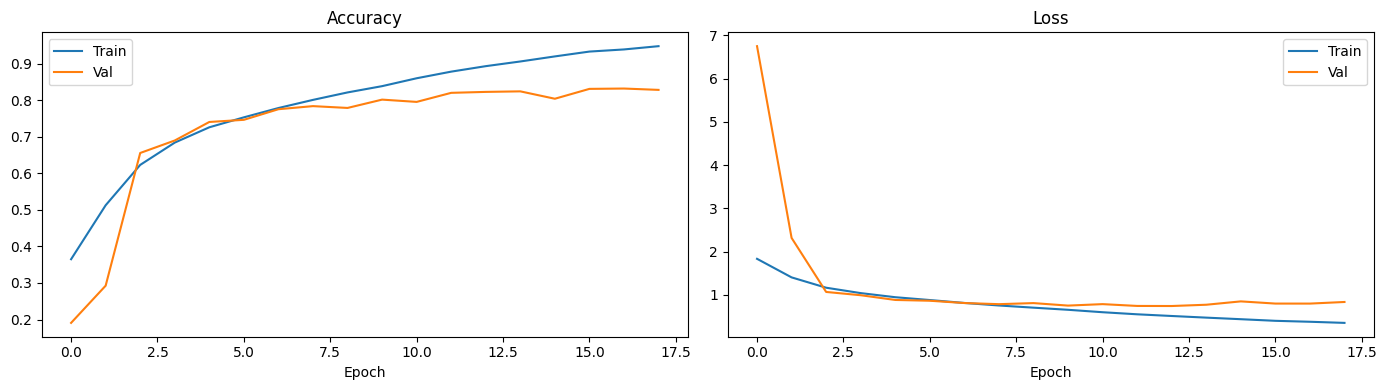

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("loss", "val_loss")],
    ["Accuracy", "Loss"]
):
    ax.plot(history.history[metric[0]], label="Train")
    ax.plot(history.history[metric[1]], label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Evaluation â€” Confusion Matrix & Classification Report

171/171 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
               precision    recall  f1-score   support

      Algebra       0.91      0.72      0.80      1572
Combinatorics       0.76      0.80      0.78      1173
     Geometry       0.95      0.91      0.93      1663
Number Theory       0.65      0.87      0.74      1039

     accuracy                           0.82      5447
    macro avg       0.82      0.82      0.81      5447
 weighted avg       0.84      0.82      0.83      5447



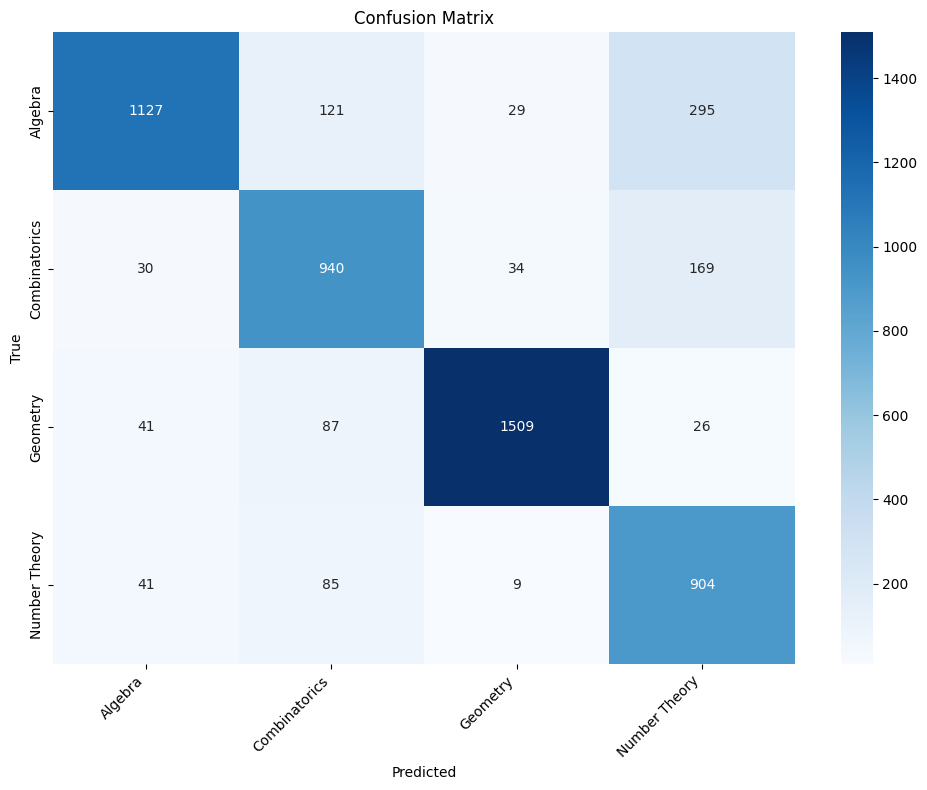

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(X_val), axis=1)

# Only use labels that appear in val set or predictions
present_labels = np.union1d(np.unique(y_val), np.unique(y_pred))
present_names = le.classes_[present_labels]

print(classification_report(y_val, y_pred, labels=present_labels, target_names=present_names))

cm = confusion_matrix(y_val, y_pred, labels=present_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=present_names, yticklabels=present_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Predict on a New Problem

In [17]:
def predict_topic(problem_text: str) -> dict:
    """Return predicted topic and confidence scores for a math problem."""
    seq = pad_sequences(
        tokenizer.texts_to_sequences([problem_text]),
        maxlen=MAX_LEN, padding="post", truncating="post"
    )
    probs   = model.predict(seq, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:3]
    return {
        "predicted_topic": le.classes_[top_idx[0]],
        "confidence":      float(probs[top_idx[0]]),
        "top_3": [
            {"topic": le.classes_[i], "score": float(probs[i])}
            for i in top_idx
        ]
    }

# Model classifies into 4 classes: Algebra, Combinatorics, Geometry, Number Theory
test_cases = [
    # Algebra
    ("Algebra — Quadratic",
     "Solve for x: 2x^2 - 4x - 6 = 0 using the quadratic formula"),
    ("Algebra — System of equations",
     "Solve the system: 3x + 2y = 12 and x - y = 1"),
    ("Algebra — Polynomial factoring",
     "Factor completely: x^3 - 6x^2 + 11x - 6"),
    ("Algebra — Logarithm",
     "Solve for x: log_2(x + 3) + log_2(x - 1) = 5"),
    ("Algebra — Exponential",
     "Solve 5^(2x-1) = 125 for x"),
    ("Algebra — Rational expression",
     "Simplify (x^2 - 9) / (x^2 - x - 6)"),
    ("Algebra — Absolute value inequality",
     "Find all x satisfying |3x - 7| < 14"),
    ("Algebra — Functional equation",
     "Find all functions f: R -> R such that f(x + y) = f(x) + f(y) for all x, y"),

    # Geometry
    ("Geometry — Triangle area",
     "Find the area of a triangle with base 8 cm and height 5 cm"),
    ("Geometry — Circle",
     "Calculate the circumference and area of a circle with radius 7"),
    ("Geometry — Volume sphere",
     "What is the volume of a sphere with radius 4?"),
    ("Geometry — Pythagorean theorem",
     "A right triangle has legs of length 6 and 8. Find the hypotenuse."),
    ("Geometry — Similar triangles",
     "Two similar triangles have corresponding sides 5 and 12. If the perimeter of the smaller is 24, find the perimeter of the larger."),
    ("Geometry — Angle chasing",
     "In triangle ABC, angle A = 70 degrees and angle B = 50 degrees. Find angle C and the exterior angle at B."),
    ("Geometry — Cyclic quadrilateral",
     "Prove that opposite angles of a cyclic quadrilateral sum to 180 degrees"),
    ("Geometry — Tangent lines",
     "Two tangents are drawn from an external point to a circle of radius 5. The distance from the point to the center is 13. Find the length of each tangent."),

    # Number Theory
    ("Number Theory — GCD",
     "Find the greatest common divisor of 252 and 198 using the Euclidean algorithm"),
    ("Number Theory — Prime",
     "Prove that there are infinitely many prime numbers"),
    ("Number Theory — Modular arithmetic",
     "Find 3^100 mod 7 using Fermat's little theorem"),
    ("Number Theory — Diophantine",
     "Find all integer solutions to 15x + 21y = 3"),
    ("Number Theory — Divisibility",
     "Show that n^3 - n is divisible by 6 for every integer n"),
    ("Number Theory — Chinese remainder theorem",
     "Find the smallest positive integer x such that x ≡ 2 (mod 3), x ≡ 3 (mod 5), x ≡ 2 (mod 7)"),
    ("Number Theory — Perfect numbers",
     "Show that 28 is a perfect number and determine whether 496 is perfect"),

    # Combinatorics
    ("Combinatorics — Permutations",
     "How many ways can 8 people be seated in a row of 8 chairs?"),
    ("Combinatorics — Combinations",
     "In how many ways can a committee of 4 be chosen from 10 people?"),
    ("Combinatorics — Pigeonhole",
     "If 13 socks of 4 colors are in a drawer, how many must you draw to guarantee a matching pair?"),
    ("Combinatorics — Graph coloring",
     "What is the chromatic number of the Petersen graph?"),
    ("Combinatorics — Invariants",
     "A 2x2019 board is to be covered with 1x2 dominoes. In how many ways can this be done?"),
    ("Combinatorics — Inclusion-exclusion",
     "How many integers from 1 to 1000 are divisible by 2, 3, or 5?"),
    ("Combinatorics — Game theory / greedy",
     "Two players alternately remove 1 or 2 stones from a pile of 20. The player who takes the last stone wins. Who has a winning strategy?"),
]

print(f"{'#':<4} {'Category':<38} {'Predicted':<18} {'Conf':>6}")
print("-" * 72)
for i, (category, problem) in enumerate(test_cases, 1):
    result = predict_topic(problem)
    predicted = result["predicted_topic"]
    conf      = result["confidence"]
    expected  = category.split(" — ")[0]
    marker    = "" if predicted == expected else f"  (expected {expected})"
    print(f"{i:<4} {category:<38} {predicted:<18} {conf:>5.1%}{marker}")

print("\n--- Top-3 scores for one problem per class ---")
area_firsts = {
    "Algebra":       test_cases[0],
    "Geometry":      test_cases[8],
    "Number Theory": test_cases[16],
    "Combinatorics": test_cases[23],
}
for area, (cat, prob) in area_firsts.items():
    r = predict_topic(prob)
    print(f"\n[{area}] {prob[:70]}")
    for t in r["top_3"]:
        print(f"  {t['topic']:<22} {t['score']:.2%}")

#    Category                               Predicted            Conf
------------------------------------------------------------------------
1    Algebra — Quadratic                    Algebra            94.2%
2    Algebra — System of equations          Number Theory      75.0%  (expected Algebra)
3    Algebra — Polynomial factoring         Algebra            94.0%
4    Algebra — Logarithm                    Algebra            100.0%
5    Algebra — Exponential                  Number Theory      55.7%  (expected Algebra)
6    Algebra — Rational expression          Algebra            98.9%
7    Algebra — Absolute value inequality    Number Theory      98.0%  (expected Algebra)
8    Algebra — Functional equation          Algebra            99.9%
9    Geometry — Triangle area               Geometry           100.0%
10   Geometry — Circle                      Geometry           100.0%
11   Geometry — Volume sphere               Geometry           100.0%
12   Geometry — Pythagorean theore

## 11. Save the Model

In [18]:
import pickle, os

os.makedirs("saved_model", exist_ok=True)
model.save("saved_model/mathnet_cnn.keras")

with open("saved_model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open("saved_model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model, tokenizer, and label encoder saved to saved_model/")

Model, tokenizer, and label encoder saved to saved_model/
